In [1]:
using Random, GMRF

include("src/dataGen.jl");
include("src/cavi.jl");
include("src/mcmc.jl");
include("src/plotting.jl");

Taille de la grille (à ne pas modifier)

In [2]:
M₁ = 3;
M₂ = 3;
M = M₁ * M₂;

- Génération de la grille cible
- Création des données artificielles

In [3]:
Random.seed!(300);
Fmu = iGMRF(M₁, M₂, 1, 10);
Fphi = iGMRF(M₁, M₂, 1, 100);
Fxi = iGMRF(M₁, M₂, 1, 100000);
gridTarget = generateTargetGrid(Fmu, Fphi, Fxi);
gridTarget[:, :, 1] = gridTarget[:, :, 1] .+ 10.0;
gridTarget[:, :, 2] = gridTarget[:, :, 2] .+ 1.0;
gridTarget[:, :, 3] = gridTarget[:, :, 3] .+ .3;
nobs = 100;
data = generateData(gridTarget, nobs);

# CAVI

In [4]:
nEpoch = 10;
epochSize = 10;

initialValues = Dict(
    :μ => zeros(M),
    :ϕ => zeros(M),
    :ξ => zeros(M),
);

spatialScheme = Dict(
    :M => M,
    :Fmu => Fmu,
    :Fphi => Fphi,
    :Fxi => Fxi,
    :data => data,
);

In [5]:
res = runCAVI(nEpoch, epochSize, initialValues, spatialScheme);

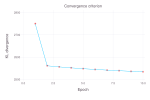

In [6]:
plotConvergenceCriterion(res.MCKL)

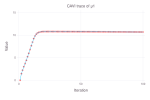

In [7]:
plotTraceCAVI(res.traces[:muMean][1, :], "μ1")

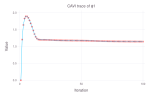

In [8]:
plotTraceCAVI(res.traces[:phiMean][1, :], "ϕ1")

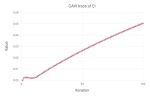

In [9]:
plotTraceCAVI(res.traces[:xiMean][1, :], "ξ1")

# MCMC

In [10]:
datastructure = Dict(
    :Y => data,
    :Fmu => Fmu,
    :Fphi => Fphi,
    :Fxi => Fxi,
);

niter = 10000;

initialvalues = Dict(
    :μ => zeros(M),
    :ϕ => zeros(M),
    :ξ => fill(.2, M),
);

stepsize = Dict(
    :μ => .8,
    :ϕ => .25,
    :ξ => .01,
);

In [11]:
include("src/mcmc.jl")

chain = mcmc(datastructure, niter, initialvalues, stepsize);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


In [12]:
changerate(chain)

             Change Rate
          μ1       0.247
          μ2       0.228
          μ3       0.238
          μ4       0.218
          μ5       0.205
          μ6       0.212
          μ7       0.238
          μ8       0.221
          μ9       0.240
          ϕ1       0.271
          ϕ2       0.244
          ϕ3       0.260
          ϕ4       0.243
          ϕ5       0.214
          ϕ6       0.229
          ϕ7       0.269
          ϕ8       0.236
          ϕ9       0.268
          ξ1       0.265
          ξ2       0.223
          ξ3       0.269
          ξ4       0.221
          ξ5       0.186
          ξ6       0.220
          ξ7       0.271
          ξ8       0.221
          ξ9       0.275
Multivariate       0.980



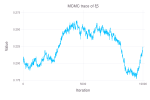

In [13]:
plotTraceMCMC(chain, "ξ5")

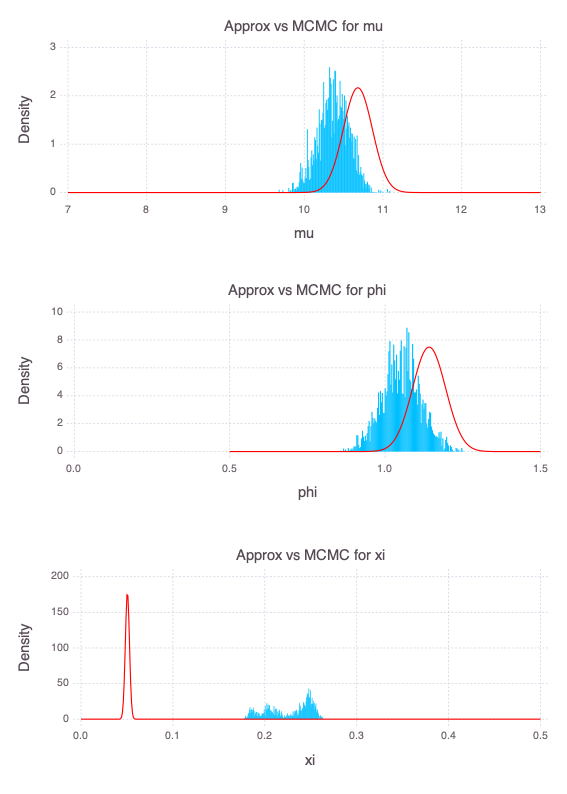

In [17]:
include("src/plotting.jl");

plotCAVIvsMCMC(1, caviRes=res, mcmcChain=chain, warmingSize=1000)

In [15]:
for marginal in res.approxMarginals
    display(round.(Matrix(params(marginal)[2]), digits=3))
end

3×3 Matrix{Float64}:
  0.034   0.001  -0.0
  0.001   0.003  -0.0
 -0.0    -0.0     0.0

3×3 Matrix{Float64}:
  0.025   0.001  -0.0
  0.001   0.002  -0.0
 -0.0    -0.0     0.0

3×3 Matrix{Float64}:
  0.032   0.002  -0.0
  0.002   0.003  -0.0
 -0.0    -0.0     0.0

3×3 Matrix{Float64}:
  0.025   0.001  -0.0
  0.001   0.002  -0.0
 -0.0    -0.0     0.0

3×3 Matrix{Float64}:
  0.02   0.0    -0.0
  0.0    0.002  -0.0
 -0.0   -0.0     0.0

3×3 Matrix{Float64}:
  0.025   0.001  -0.0
  0.001   0.002  -0.0
 -0.0    -0.0     0.0

3×3 Matrix{Float64}:
  0.032   0.001  -0.0
  0.001   0.003  -0.0
 -0.0    -0.0     0.0

3×3 Matrix{Float64}:
  0.025   0.001  -0.0
  0.001   0.002  -0.0
 -0.0    -0.0     0.0

3×3 Matrix{Float64}:
  0.033   0.002  -0.0
  0.002   0.003  -0.0
 -0.0    -0.0     0.0